In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
from pathlib import Path

In [2]:
datasets = Path('Datasets')
title = 'El conde de Montecristo - Alexandre Dumas'

if not Path(datasets / f'{title}.txt').exists():
    epub_file = f'datasets/raw/{title}.epub'
    txt_file = f'datasets/{title}.txt'
    !ebook-convert "{epub_file}" "{txt_file}"

In [3]:
with open(f'datasets/{title}.txt', 'r') as f:
    doc = list(map(lambda x: x.lower(), f.read().split()))

print('length of document:', len(doc))
print('first 10 elements:', doc[:10])
print('last 10 elements:', doc[-10:])

length of document: 470383
first 10 elements: ['el', 'conde', 'de', 'montecristo', 'es', 'uno', 'de', 'los', 'clásicos', 'más']
last 10 elements: ['libro', 'de', 'las', 'aventuras', 'de', 'telémaco', 'de', 'fénelon', '(1694-1696).', '<<']


In [4]:
word_count_table = dict()
word_location_table = dict()

for i, word in enumerate(doc):
    #  TODO: find better discriminatory function, maybe implement stanford tokenizer
    if word.isalpha():
        last_count = word_count_table.get(word, 0)
        word_count_table.update({word: last_count + 1})

        locations = word_location_table.get(word, [])
        word_location_table.update({word: locations + [i]})

print('number of alphabetic words:', len(word_count_table.keys()))

number of alphabetic words: 23113


In [5]:
min_word_count, max_word_count = 5, int(1e6)
word_count_table = {w: count for w, count in word_count_table.items() if min_word_count < count < max_word_count}

In [6]:
words = random.sample(list(word_count_table.keys()), 2_000)

for i, w in enumerate(['padre', 'madre', 'hombre', 'mujer']):
    if w not in words:
        words[i] = w
    else:
        loc = words.index(w)
        words[i], words[loc] = words[loc], words[i]

num_words = len(words)
X = np.zeros((num_words, num_words))

context_size = 10

for i in range(num_words):
    wi = words[i]

    locations = word_location_table[wi]

    print('\nword:', wi, '-- locations:', locations)
    
    for loc in locations:
        for j in range(num_words):
            if words[j] in doc[loc-context_size: loc+context_size]:
                X[i, j] += 1


word: padre -- locations: [186, 233, 574, 2496, 3016, 3057, 3265, 3568, 4024, 4129, 4397, 4502, 4797, 5242, 5354, 5378, 5508, 5519, 5544, 5649, 7218, 11947, 12935, 13013, 13991, 14155, 14342, 14381, 15098, 15798, 15873, 15937, 18196, 18205, 18213, 18295, 18413, 19547, 19562, 19745, 20483, 24435, 24957, 24959, 28331, 31429, 37194, 37346, 37402, 37739, 38618, 38685, 38713, 39078, 39109, 39617, 40303, 41960, 42215, 43110, 44391, 53200, 53227, 58811, 59662, 63431, 65245, 65484, 66139, 68213, 92155, 92449, 93501, 94514, 95420, 95710, 96342, 96710, 96948, 97275, 97325, 98266, 99566, 103265, 104578, 104580, 108224, 108944, 108989, 109013, 109086, 109255, 109425, 109501, 109958, 109995, 110090, 110236, 110398, 110599, 110843, 110868, 110870, 111190, 111915, 128446, 128475, 128501, 128524, 128881, 129715, 129940, 130081, 130112, 130142, 130290, 132546, 162569, 168936, 174206, 174239, 177586, 179952, 180873, 180901, 181157, 190057, 195853, 210093, 211339, 211354, 211367, 211525, 211681, 211695,

In [7]:
Xi = np.sum(X, axis=1)

words, Xi = zip(*sorted(zip(words, Xi), key=lambda w_xi: word_count_table[w_xi[0]], reverse=True))

In [8]:
print("number of words:", num_words)
print(words[:20])
print(words[-20:])

number of words: 2000
('la', 'a', 'no', 'una', 'con', 'su', 'como', 'pero', 'era', 'o', 'dos', 'sobre', 'estaba', 'todo', 'tan', 'hombre', 'solo', 'vez', 'ese', 'muy')
('ceder', 'pedrusco', 'ocuparse', 'romana', 'aturdido', 'escultor', 'ciencias', 'tendió', 'numerosos', 'melancólica', 'sección', 'ajeno', 'despierta', 'arrestado', 'lindero', 'llamas', 'rechinar', 'representantes', 'mazmorras', 'esperemos')


# SVD Embedding 

In [9]:
U, S, Vt = np.linalg.svd(X)

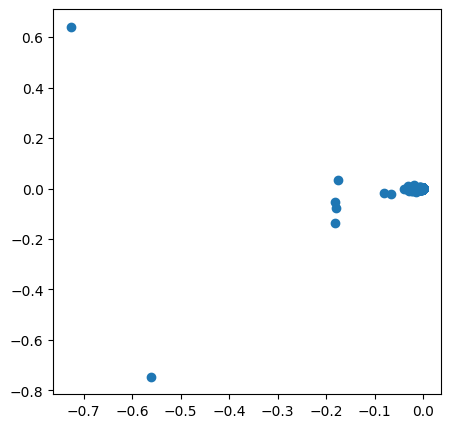

In [10]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(U[:, 0], U[:, 1])

plt.show()

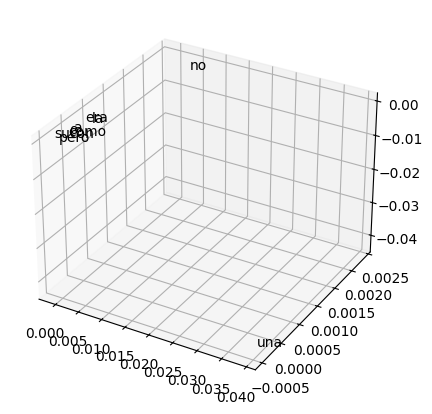

In [11]:
fig, ax = plt.subplots(figsize=(5, 5), subplot_kw={"projection": "3d"})

dim0, dim1, dim2 = 5, 1, 2

for i, u in enumerate(U[5:15]):
    ax.plot(u[dim0], u[dim1], u[dim2])
    ax.text(u[dim0], u[dim1], u[dim2], words[i])

plt.show()

# GloVe

In [12]:
import torch
import torch.nn as nn

In [13]:
torch.set_default_dtype(torch.float64)

In [14]:
class GloVe:
    alpha = 0.75
    xmax = 100
    
    def __init__(self, X, enc_dim):
        self.X = torch.tensor(X)
        self.FX = torch.ones_like(self.X)
        self.FX[self.X < self.xmax] = (self.X[self.X < self.xmax] / self.xmax)**self.alpha
        self.LogX = torch.log(1 + self.X)

        N = X.shape[0]
        self.glove_center = torch.randn(N, enc_dim) / np.sqrt(N)
        self.glove_context = torch.randn(N, enc_dim) / np.sqrt(N)

        self.glove_context.requires_grad_()
        self.glove_center.requires_grad_()

        self.curr_iter = 0
        self.best_glove_center = None
        self.best_glove_context = None
        self.best_loss = float('infinity')

    def loss(self, w, v):
        return torch.sum(self.FX * (w @ v.T - self.LogX)**2)

    def best_embedding(self):
        return (self.best_glove_center + self.best_glove_context).detach()

    def train(self, n_iter, lr=0.01, max_lr=0.1, show=True):
        glove_opt = torch.optim.Adam([self.glove_center, self.glove_context], lr=lr)
        glove_scheduler = torch.optim.lr_scheduler.OneCycleLR(glove_opt, max_lr=max_lr, total_steps=n_iter)
        
        for n in range(n_iter):
            loss = self.loss(self.glove_center, self.glove_context)

            if show:
                print(f'iteration: {self.curr_iter + n:3d}, loss: {loss.item()}', end='\r')
            
            loss.backward()
            
            with torch.no_grad():
                if loss.item() < self.best_loss:
                    self.best_loss = loss.item()
                    self.best_glove_center = self.glove_center.detach().clone()
                    self.best_glove_context = self.glove_context.detach().clone()

                glove_opt.step()
                glove_scheduler.step()
                
                glove_opt.zero_grad()


        self.curr_iter += n_iter
        return self.best_embedding()

    def save(self, filename='glove.pt'):
        if self.best_loss is not None:
            torch.save({
                'center': self.best_glove_center,
                'context': self.best_glove_context,
                'loss': self.best_loss,
                'iteration': self.curr_iter,
            }, filename)

    def load(self, filename='glove.pt'):
        data = torch.load(filename)
        self.best_loss = data.get('loss')
        self.best_glove_center = data.get('center')
        self.best_glove_context = data.get('context')
        self.curr_iter = data.get('iteration')

In [26]:
enc_dim = 50
glove = GloVe(X, enc_dim)

In [51]:
Phi = glove.train(100, lr=0.01, max_lr=0.03)

iteration: 699, loss: 53.089088462977586

In [52]:
glove.save(f'embd/{title} -- {enc_dim}.pt')

In [53]:
idx_padre, idx_madre = words.index('padre'), words.index('madre')
idx_hombre, idx_mujer = words.index('hombre'), words.index('mujer')

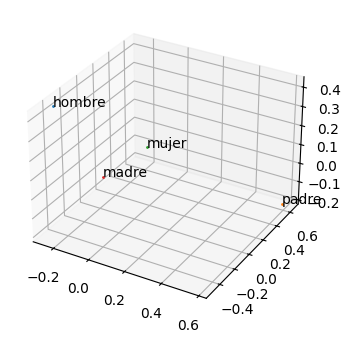

In [54]:
fig, ax = plt.subplots(figsize=(4, 4), subplot_kw={'projection': '3d'})

for idx in [idx_hombre, idx_padre, idx_mujer, idx_madre]:
    ax.plot(Phi[idx][0], Phi[idx][1], Phi[idx][2], 'o', markersize=1)
    ax.text(Phi[idx][0], Phi[idx][1], Phi[idx][2], words[idx])

plt.show()

In [55]:
Phi_norm_squared = torch.linalg.norm(Phi, axis=1)**2

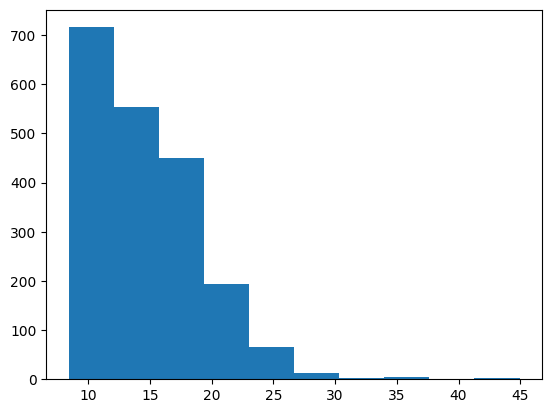

permanecía


In [56]:
plt.hist(Phi_norm_squared)
plt.show()

idx_max = torch.argmax(Phi_norm_squared)
print(words[idx_max])

In [57]:
def knn(idx, k=1):
    ''' returns the k nearest neighbors of word idx '''
    return torch.argsort(Phi[idx] @ Phi[idx] + Phi_norm_squared - 2 * Phi[idx]@Phi.T)[:k+1]

In [58]:
for idx in [idx_hombre, idx_padre, idx_mujer, idx_madre]:
    idx_knn = knn(idx, k=5)
    
    print(f'Closest to \'{words[idx]}\':', end=' ')
    for idx_ in idx_knn:
        print(f'\'{words[idx_]}\'', end=', ')
    print()

Closest to 'hombre': 'hombre', 'magistrado', 'barca', 'encuentran', 'romper', 'vergüenza', 
Closest to 'padre': 'padre', 'nuevo', 'junto', 'rayo', 'respecto', 'hacernos', 
Closest to 'mujer': 'mujer', 'tomaré', 'cuestión', 'catalán', 'sitio', 'levantaba', 
Closest to 'madre': 'madre', 'conocía', 'crisis', 'apretando', 'perros', 'lectura', 


In [59]:
(Phi[idx_hombre] - Phi[idx_mujer]) @ (Phi[idx_padre] - Phi[idx_madre])

tensor(-2.4990)

In [60]:
Phi[idx_hombre] @ Phi[idx_mujer], Phi[idx_padre] @ Phi[idx_madre]

(tensor(4.0807), tensor(4.8772))

# Poincare GloVe